In [1]:
using CloudAtlas
using LinearAlgebra
using Base.Threads
using CairoMakie
using DifferentialEquations
using Dates
using LinearAlgebra
using Statistics
using ChannelflowWrapper

In [2]:
struct SolutionFingerprint
    cx::Float64
    cz::Float64
    nm::Float64
end

function get_fingerprint(model, ξ)
    # Extract physical components (assuming ξ = [x..., cx, cz] based on TWModel)
    x, cx, cz = extract_components(ξ, model)
    return SolutionFingerprint(cx, cz, norm(x))
end

function is_distinct(new_fp::SolutionFingerprint, archive::Vector{SolutionFingerprint}; tol=1e-2)
    for fp in archive
        # Check wave speeds and norm
        if isapprox(new_fp.cx, fp.cx, atol=tol) && 
           isapprox(new_fp.cz, fp.cz, atol=tol) && 
           isapprox(new_fp.nm, fp.nm, atol=tol)
            return false # Duplicate found
        end
    end
    return true
end

is_distinct (generic function with 1 method)

In [3]:
"""
    find_fixed_points(model, Re; n_attempts=50, xnorm=0.4)

Searches for unique Traveling Wave solutions for a specific model/discretization.
Returns a vector of solution vectors ξ (state + speeds).
"""
function find_fixed_points(model::TWModel, Re::Real; n_attempts=50, xnorm=0.4, hookparams=CloudAtlas.SearchParams())
    
    m = length(model)
    solutions = Vector{Vector{Float64}}()
    fingerprints = Vector{SolutionFingerprint}()
    
    # Thread-safe locks
    data_lock = ReentrantLock()
    io_lock = ReentrantLock()
    
    println("Starting search for TW solutions (Re=$Re, Attempts=$n_attempts)...")
    
    @threads for i in 1:n_attempts
        print(".")
        # 1. Random Initial Guess
        x_guess = randn(m)
        x_guess = xnorm / norm(x_guess) * x_guess
        
        # Small random wave speeds to break symmetry
        cx_guess = model.keep_cx ? randn() * 0.1 : 0
        cz_guess = model.keep_cz ? randn() * 0.1 : 0
        ξ_guess = [x_guess; cx_guess; cz_guess]

        # 2. Solver Wrappers
        f(ξ) = model.g(ξ, Re)
        Df(ξ) = model.Dg(ξ, Re)
        
        # 3. Solve
        # Note: hookstepsolve must be imported or available
        ξ_star, converged = CloudAtlas.hookstepsolve(f, Df, ξ_guess, hookparams)
        
        # 4. Validation & Storage
        if converged
            # Check basic physical properties (non-trivial solution)
            x_sol = ξ_star[1:m]
            cx = ξ_star[m+1]
            cz = ξ_star[m+2]
            if norm(x_sol) > 1e-2 && (cx > 0 || cz > 0)
                fp = get_fingerprint(model, ξ_star)
                
                lock(data_lock) do
                    if is_distinct(fp, fingerprints)
                        push!(fingerprints, fp)
                        push!(solutions, ξ_star)
                        lock(io_lock) do 
                            println("  \n[Thread $(threadid())] Found unique TW: cx=$(round(fp.cx, digits=4)), |x|=$(round(fp.nm, digits=4))")
                        end
                    end
                end
            end
        end
    end
    
    println("Search complete. Found $(length(solutions)) unique solutions.")
    return solutions
end

find_fixed_points

In [4]:
"""
    generate_turbulent_trajectory(model, Re, tspan; xnorm=0.4)

Generates a time-evolution trajectory starting from a random initial condition.
Returns the ODE solution object.
"""
function generate_turbulent_trajectory(model::TWModel, Re::Real, tspan; xnorm=0.4)
    println("Integrating turbulent trajectory over t=$tspan...")
    
    m = length(model)
    
    # Random initial condition for state x (no wave speeds needed for ODE init x0)
    x0 = randn(m)
    x0 = xnorm / norm(x0) * x0
    
    # We must construct a full ξ vector for integrate_flow, even if we assume cx=cz=0 initially
    # integrate_flow handles the ξ unpacking internally.
    ξ_init = [x0; 0.0; 0.0] 
    
    # Run integration (lab_frame=true effectively simulates DNS)
    sol = integrate_flow(model, ξ_init, tspan; R=Re, saveat=0.5, lab_frame=true)
    
    return sol
end

generate_turbulent_trajectory

In [5]:
"""
    plot_phase_space_map(model, tw_solutions, traj_sol)

Plots the (I, D) phase portrait.
- Blue dots: Traveling Wave solutions (Fixed Points)
- Black line: Time evolution trajectory
- Dashed line: Laminar/Equilibrium (I=D)
"""
function plot_phase_space_map(model::TWModel, tw_solutions::Vector, traj_sol, D_matrix = nothing)
    
    # 1. Build Dissipation Matrix (expensive, do once)
    if isnothing(D_matrix)
        println("Building dissipation matrix...")
        D_matrix = build_dissipation_matrix(model)
    end
    
    # 2. Calculate I/D for Fixed Points (TWs)
    I_tws = Float64[]
    D_tws = Float64[]
    
    for ξ in tw_solutions
        x, _, _ = extract_components(ξ, model)
        push!(I_tws, power_input(model, x))
        push!(D_tws, dissipation_rate(D_matrix, x))
    end
    
    # 3. Calculate I/D for Trajectory
    println("Calculating metrics for trajectory...")
    I_traj = [CloudAtlas.power_input(model, u) for u in traj_sol.u]
    D_traj = [CloudAtlas.dissipation_rate(D_matrix, u) for u in traj_sol.u]
    
    # 4. Plotting
    fig = Figure(size=(800, 600))
    ax = Axis(fig[1, 1], 
        title="State Space: Power Input vs Dissipation",
        xlabel="Dissipation Rate (D)", 
        ylabel="Power Input (I)"
    )
    
    # Plot Trajectory
    lines!(ax, D_traj, I_traj, color=:black, alpha=0.6, label="Turbulent Trajectory")
    # Mark start and end of trajectory
    scatter!(ax, [D_traj[1]], [I_traj[1]], color=:green, marker=:circle, label="Start")
    scatter!(ax, [D_traj[end]], [I_traj[end]], color=:red, marker=:x, label="End")

    # Plot Fixed Points (TWs)
    scatter!(ax, D_tws, I_tws, color=:blue, markersize=20, label="TW Solutions")
    
    # Plot I=D Line (Equilibrium)
    # Find plot limits to draw the line nicely
    all_D = [D_tws; D_traj]
    all_I = [I_tws; I_traj]
    min_val = min(minimum(all_D), minimum(all_I)) * 0.9
    max_val = max(maximum(all_D), maximum(all_I)) * 1.1
    
    lines!(ax, [min_val, max_val], [min_val, max_val], linestyle=:dash, color=:grey, label="Laminar (I=D)")
    
    axislegend(ax, position=:lt)
    
    return fig
end

plot_phase_space_map

In [6]:
"""
    find_trajectory_minima(model, sol, D_matrix)

Analyzes a trajectory to find 'Slow Points' in the I-D phase plane.
Returns a list of (time_index, state_vector) tuples to use as Newton guesses.
"""
function find_trajectory_minima(model, sol, D_matrix; window=5)
    # Compute I and D time series
    I_vals = [CloudAtlas.power_input(model, u) for u in sol.u]
    D_vals = [CloudAtlas.dissipation_rate(D_matrix, u) for u in sol.u]
    
    # compute "Phase Velocity" in I-D plane (simple finite difference)
    # velocity ~ sqrt((dI/dt)^2 + (dD/dt)^2)
    vel_id = zeros(length(sol.t))
    
    for i in 2:length(sol.t)
        dt = sol.t[i] - sol.t[i-1]
        dI = (I_vals[i] - I_vals[i-1]) / dt
        dD = (D_vals[i] - D_vals[i-1]) / dt
        vel_id[i] = sqrt(dI^2 + dD^2)
    end
    
    # Find Local Minima (The system is "lingering" near a solution)
    guesses = []
    
    # Simple peak/trough detection
    for i in 1+window : length(vel_id)-window
        # Check if this point is smaller than its neighbors in the window
        local_segment = vel_id[i-window : i+window]
        if vel_id[i] == minimum(local_segment) && vel_id[i] < 0.5 # Threshold helps filter noise
            
            # Construct the guess vector ξ for the Newton solver
            x_guess = sol.u[i]
            
            # small random perturbations help avoid singular jacobians
            cx_guess = model.keep_cx ? randn() * 0.01 : 0
            cz_guess = model.keep_cz ? randn() * 0.01 : 0
            
            ξ_guess = [x_guess; cx_guess; cz_guess]
            
            push!(guesses, (sol.t[i], ξ_guess))
        end
    end
    
    return guesses, I_vals, D_vals, vel_id
end

find_trajectory_minima

In [7]:
"""
    harvest_solutions_from_trajectory(model, Re, sol)

Runs the Newton solver starting from "Slow Points" in the trajectory.
"""
function harvest_solutions_from_trajectory(model::TWModel, Re::Real, sol)
    # 1. Precompute matrix
    D_mat = CloudAtlas.build_dissipation_matrix(model)
    
    # 2. Find promising start points
    candidates, I_vals, D_vals, vel = find_trajectory_minima(model, sol, D_mat)
    
    println("Found $(length(candidates)) candidate snapshots from trajectory.")
    
    solutions = []
    
    # 3. Newton Search
    # Reuse the logic from your fuzzing code
    hookparams = CloudAtlas.SearchParams(Nnewton=40, Nhook=5) # More generous for these guesses
    
    f(ξ) = model.g(ξ, Re)
    Df(ξ) = model.Dg(ξ, Re)

    for (t_val, ξ_guess) in candidates
        print("  Searching from snapshot at t=$t_val... ")
        ξ_star, converged = CloudAtlas.hookstepsolve(f, Df, ξ_guess, hookparams)
        
        if converged
            # Check if it's a trivial solution (Laminar flow has norm ≈ 0 usually, depending on basis)
            # Assuming basis is perturbation, laminar is 0.
            m = length(model)
            x_sol = ξ_star[1:m]
            cx = ξ_star[m+1]
            cz = ξ_star[m+2]
            if norm(x_sol) > 1e-3 && (cx > 0 || cz > 0)
                println("Converged! (Speeds: $(ξ_star[end-1]), $(ξ_star[end]))")
                push!(solutions, ξ_star)
            else
                println("Converged to Laminar (trivial).")
            end
        else
            println("Failed.")
        end
    end
    
    return unique(solutions), I_vals, D_vals, candidates
end

harvest_solutions_from_trajectory

In [8]:
"""
    classify_state(model, ξ, Re, T_test; D_threshold=1.001)

Integrates a state for time T_test. Returns :laminar if it decays, :turbulent if it sustains.
Uses Dissipation (D) as the metric. Laminar D = 1.0 (normalized).
"""
function classify_state(model, ξ, Re, T_test; D_threshold=1.01)
    # Integrate in Lab Frame (physically correct for evolution)
    # We use a coarse tolerance for speed, we just need the trend.
    try
        sol = integrate_flow(model, ξ, (0.0, T_test); R=Re, saveat=T_test, lab_frame=true)
        
        # Check final state
        u_final = sol.u[end]
        
        # Calculate Dissipation
        # (Assuming you can build or pass the D matrix, or just use norm)
        # Using simple L2 norm of perturbation is often enough:
        # Laminar has norm ≈ 0.
        nm = norm(u_final[1:length(model)]) # Extract just the x part
        
        if nm < 0.05
            return :laminar
        else
            return :turbulent
        end
    catch e
        # If integration fails (blow up), it's definitely not laminar
        return :turbulent
    end
end

classify_state

In [9]:
"""
    track_edge(model, Re, x_seed; n_bisect=15, T_window=100.0)

Performs edge tracking (bisection) on the amplitude of x_seed.
Returns the 'Edge State' trajectory which stays between Laminar and Turbulent.
"""
function track_edge(model, Re, x_seed; n_bisect=15, T_window=100.0)
    m = length(model)
    
    # Bracketing interval for amplitude factor α
    # [Lower (Laminar), Upper (Turbulent)]
    # We assume 0.0 is laminar. We need to find an Upper that is turbulent.
    α_lower = 0.0
    α_upper = 1.0 
    
    # 1. Establish Upper Bound (Verify x_seed is strong enough)
    println("Verifying upper bound...")
    ξ_test = [α_upper * x_seed; 0.0; 0.0]
    status = classify_state(model, ξ_test, Re, T_window)
    
    if status == :laminar
        println("Warning: Initial seed decays even at amplitude 1.0. Increasing magnitude...")
        x_seed = 5.0 * x_seed / norm(x_seed) # Boost and retry
        # In a real script, you'd loop here to find a bursting seed.
    end

    # 2. Bisection Loop
    println("Starting Edge Tracking (Bisection)...")
    
    current_x = x_seed
    best_edge_ξ = nothing
    
    for i in 1:n_bisect
        α_mid = (α_lower + α_upper) / 2.0
        
        # Construct full state vector (assuming cx=cz=0 for integration)
        ξ_mid = [α_mid * x_seed; 0.0; 0.0]
        
        status = classify_state(model, ξ_mid, Re, T_window)
        
        println("  Iter $i: α=$α_mid -> $status")
        
        if status == :laminar
            α_lower = α_mid # We need more energy
        else
            α_upper = α_mid # We need less energy
        end
    end
    
    # 3. Refinement Run
    # Run the best estimate for a longer time to let it settle onto the saddle
    println("Bisection complete. Refining edge state...")
    α_edge = (α_lower + α_upper) / 2.0
    ξ_edge = [α_edge * x_seed; 0.0; 0.0]
    
    # Integrate for a while to let the fast stable manifolds decay,
    # leaving us on the slow unstable manifold (the TW).
    sol_edge = integrate_flow(model, ξ_edge, (0.0, 300.0); R=Re, saveat=1.0, lab_frame=true)
    
    return sol_edge
end

track_edge

In [10]:
"""
    estimate_wave_speed(model, u_current, u_prev, dt)

Estimates the streamwise wave speed cx by tracking the phase shift 
of the fundamental Fourier mode (kx=1) between two snapshots.
"""
function estimate_wave_speed(model, u_current, u_prev, dt)
    # 1. Find the index of the fundamental streamwise mode (kx=1, kz=0)
    # We look for the first basis function where u[1].ejx.waveindex == 1
    idx = findfirst(psi -> psi.u[1].ejx.waveindex == 1, model.Ψ)
    
    if idx === nothing
        # Fallback if no kx=1 mode exists (unlikely in TWs)
        return 0.0
    end
    
    # 2. Extract coefficients (complex)
    # Note: u vectors are real coefficients of basis functions.
    # We need to interpret the pair (cos, sin) to get phase, or 
    # if the basis is strictly real (sin/cos), we might need to look at the pair.
    
    # If mode 'idx' is sin(ax), we likely have a partner cos(ax) nearby.
    # However, simpler heuristic: 
    # The time derivative of a mode u_k is roughly -i*k*alpha*c*u_k.
    # So du/dt ≈ -c * d/dx.
    
    # Let's use a correlation approach which is robust for Real basis functions:
    # min_c || u_current(x) - u_prev(x - c*dt) ||
    # In spectral space: u_current ≈ u_prev - c*dt * dx(u_prev)
    # c ≈ < u_prev - u_current, dx(u_prev) > / || dx(u_prev) ||^2 / dt
    
    # Construct dx(u_prev) using the spectral derivative matrix Cx
    # (Assuming model.Cx is available and precomputed)
    dx_u = model.Cx * u_prev
    
    # Projection of difference onto the advection direction
    diff = u_prev - u_current
    
    # c = (diff · dx_u) / (dx_u · dx_u) / dt
    numerator = dot(diff, dx_u)
    denominator = dot(dx_u, dx_u)
    
    if abs(denominator) < 1e-10
        return 0.0
    end
    
    return numerator / (denominator * dt)
end

estimate_wave_speed

In [11]:
function harvest_solutions_smart(model::TWModel, Re::Real, sol)
    solutions = []
    D_mat = build_dissipation_matrix(model)
    candidates, _, _, _ = find_trajectory_minima(model, sol, D_mat)
    
    # If no slow points found (e.g. erratic edge), just try the final state
    if isempty(candidates)
        push!(candidates, (sol.t[end], [sol.u[end]; 0.0; 0.0])) # Placeholder
    end

    println("Attempting harvest from $(length(candidates)) snapshots...")

    for (t_val, _) in candidates
        # Find index in solution
        idx = findfirst(t -> t >= t_val, sol.t)
        if idx <= 1; idx = 2; end
        
        u_curr = sol.u[idx]
        u_prev = sol.u[idx-1]
        dt = sol.t[idx] - sol.t[idx-1]
        
        c_est = estimate_wave_speed(model, u_curr, u_prev, dt)
        ξ_guess = [u_curr; c_est; 0]
        
        print("  t=$t_val (c_est=$(round(c_est, digits=4)))... ")

        # Use more robust hookstep parameters for this sensitive search
        hookparams = SearchParams(
            Nnewton=40, 
            Nhook=10,        
            δ=0.01,          
            ftol=1e-6  
        )
        
        f(ξ) = model.g(ξ, Re)
        Df(ξ) = model.Dg(ξ, Re)

        ξ_star, converged = CloudAtlas.hookstepsolve(f, Df, ξ_guess, hookparams)
        
        # Check Result
        m = length(model)
        nm = norm(ξ_star[1:m])
        
        if converged && nm > 0.05 # Threshold above laminar
            println("SUCCESS! Found TW (norm=$(round(nm, digits=3)), cx=$(round(ξ_star[end-1], digits=4)))")
            push!(solutions, ξ_star)
        elseif converged
            println("Laminar.")
        else
            println("Diverged.")
        end
    end
    
    return unique(solutions)
end

harvest_solutions_smart (generic function with 1 method)

In [24]:
# --- Configuration ---
α, γ = 2π/6.0, 2π/4.0 
Re = 400.0
# Define Discretization
J, K, L = 1, 2, 3
sx, sy, sz, tx, tz = CloudAtlas.halfbox_symmetries()
# H = [sx*sy*sz]
# H = [sz]
# H = [sx*tz]
# H = [sz*tx]

H = [(sx*sy)*(tx*tz)]

# --- 1. Initialize Model ---
model = TWModel(α, γ, J, K, L, H)
model.m

J,K,L,m == 1,2,3,53
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B, A1, A2, Cx, Cz...
Phase constraints: keep_cx = false, keep_cz = true
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 


53

In [25]:
D_matrix = build_dissipation_matrix(model);

Building dissipation matrix...


Integrating turbulent trajectory over t=(0.0, 1000.0)...


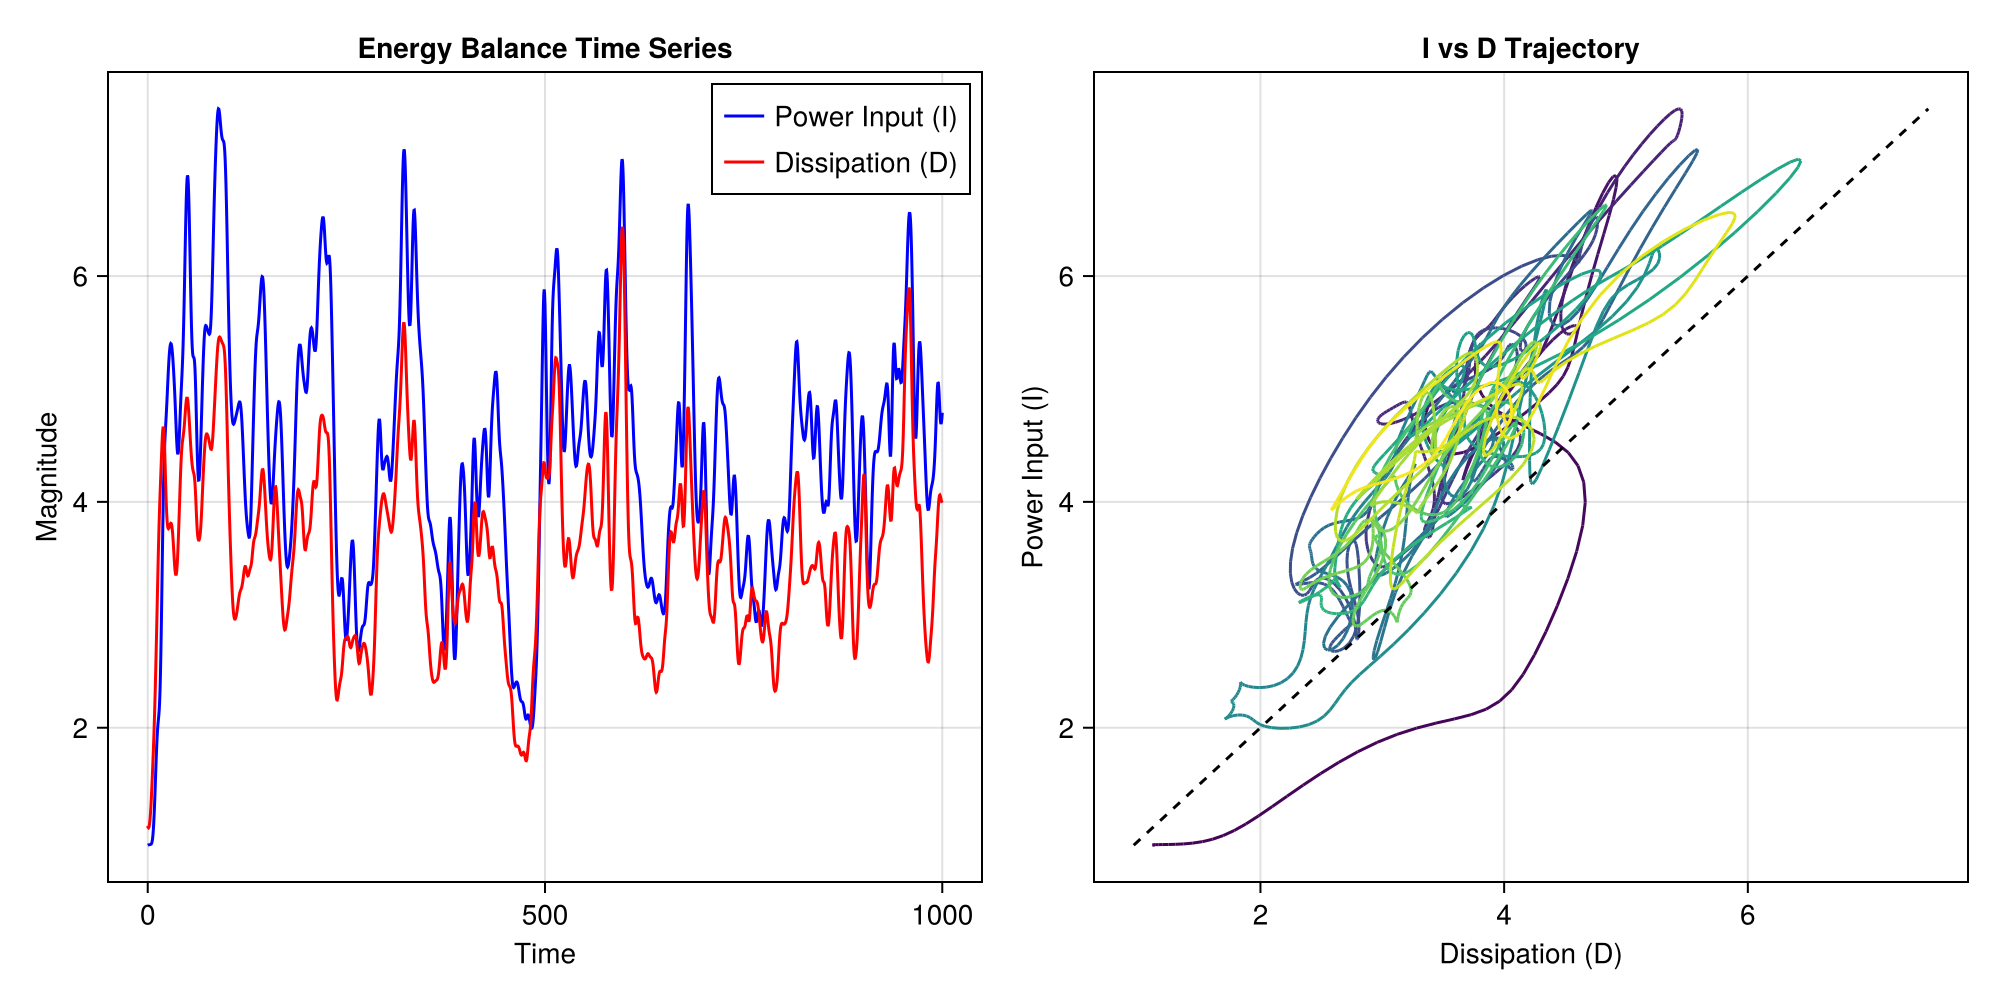

In [26]:
trajectory_sol = generate_turbulent_trajectory(model, Re, (0.0, 1000.0); xnorm=0.1)
plot_id_series(model, trajectory_sol, D_matrix)

Integrating turbulent trajectory over t=(0.0, 1000.0)...
Building dissipation matrix...
Found 121 candidate snapshots from trajectory.
  Searching from snapshot at t=10.5... Failed.
  Searching from snapshot at t=14.0... Failed.
  Searching from snapshot at t=18.0... Failed.
  Searching from snapshot at t=29.5... Failed.
  Searching from snapshot at t=40.0... Failed.
  Searching from snapshot at t=46.0... Failed.
  Searching from snapshot at t=51.5... Failed.
  Searching from snapshot at t=62.0... Failed.
  Searching from snapshot at t=80.0... Converged! (Speeds: 0.0, 0.014555962774162648)
  Searching from snapshot at t=84.5... Converged to Laminar (trivial).
  Searching from snapshot at t=102.5... Converged to Laminar (trivial).
  Searching from snapshot at t=113.5... Converged to Laminar (trivial).
  Searching from snapshot at t=118.5... Failed.
  Searching from snapshot at t=129.0... Failed.
  Searching from snapshot at t=144.0... Failed.
  Searching from snapshot at t=149.5... Fail

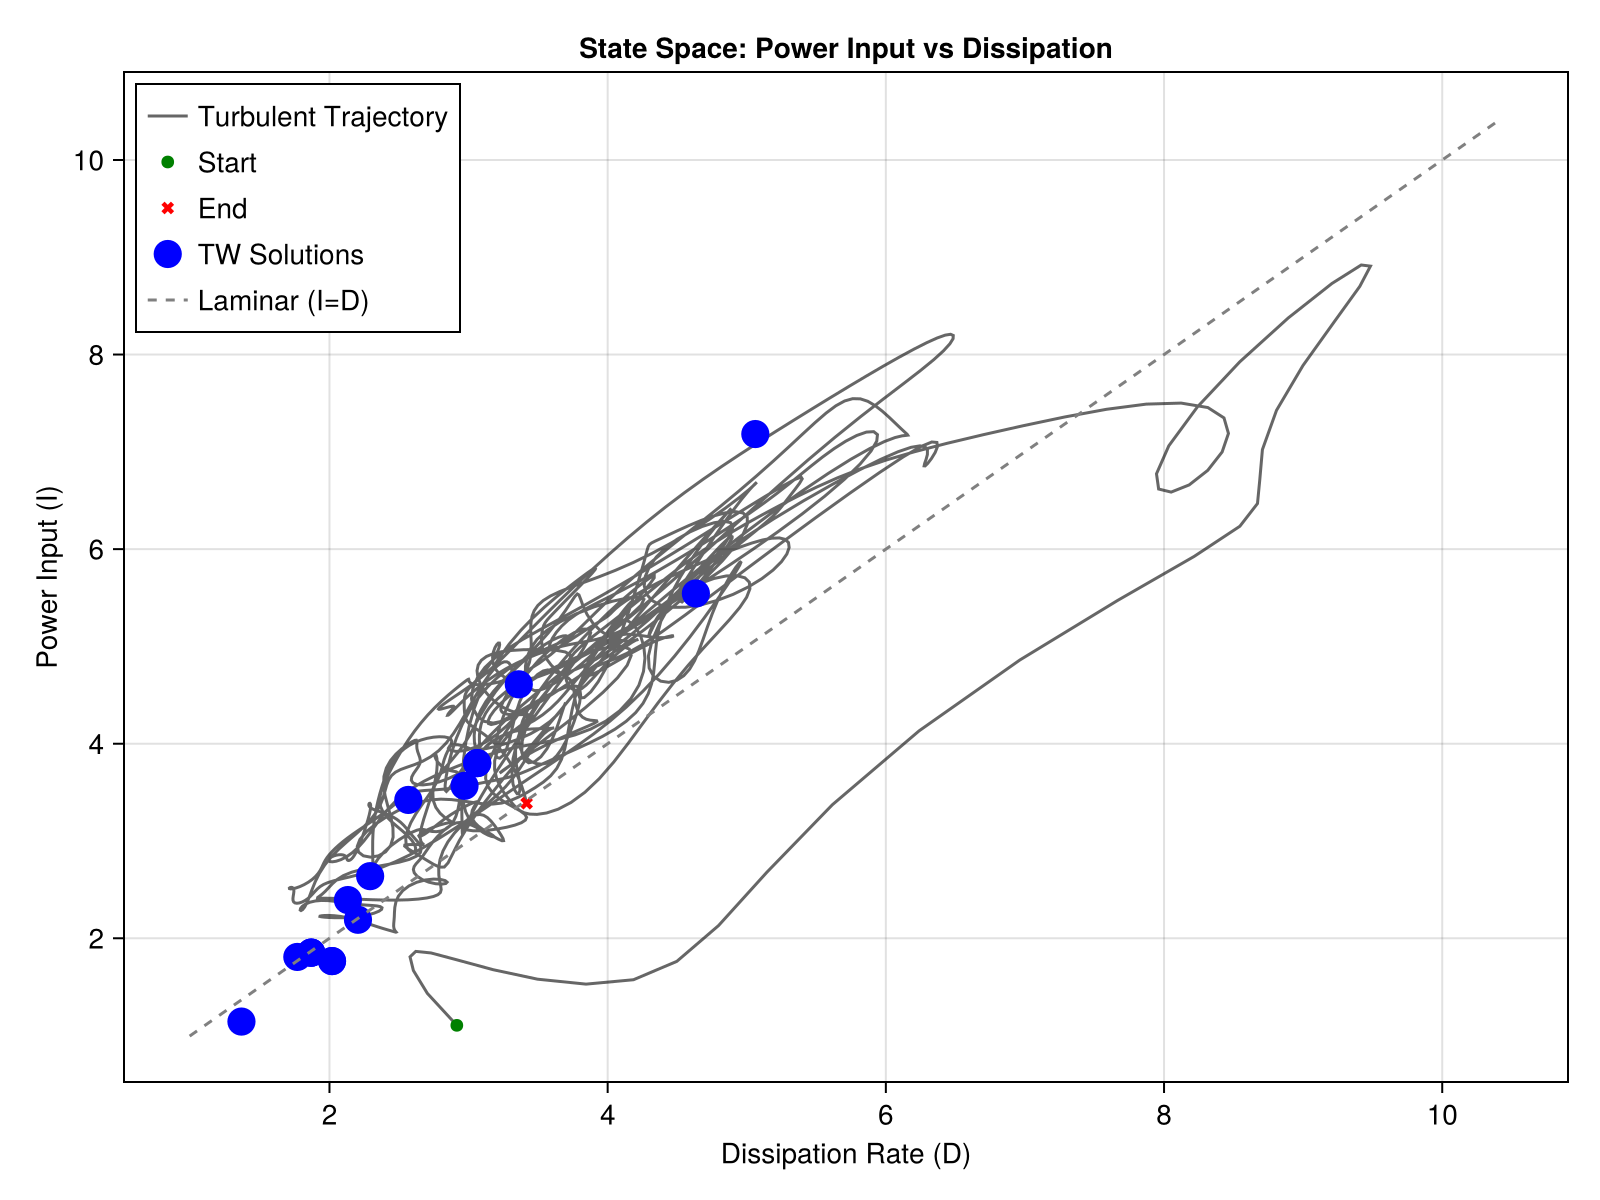

In [27]:
# 1. Generate a long turbulent trajectory (e.g., T=500 or 1000)
# Start from a random kick if you don't have one yet.
long_sol = generate_turbulent_trajectory(model, Re, (0.0, 1000.0); xnorm=0.3)

# 2. Harvest solutions
new_solutions, I, D, candidates = harvest_solutions_from_trajectory(model, Re, long_sol)

# 3. Plot the results
# This will show the trajectory, the points you picked (Slow Points), and the final converged solutions
fig = plot_phase_space_map(model, new_solutions, long_sol)

# (Optional) Overlay the candidate start points to verify logic
# You'll need to manually add scatter points for the candidates' I/D values

In [16]:
reference_field_converted = "reference_field_$(α)_$(γ).nc"
reference_path = "./TW1-2pi1piRe200-40x49x40.nc"
changegrid(reference_path, reference_field_converted; al=α, ga=γ);

Leaving rescale
L2Norm(u0)  == 0.2792590266581449
L2Norm(u1)  == 0.2792590266581447
bcNorm(u0)  == 8.737886593015271e-17
bcNorm(u1)  == 7.538105990587311e-17
divNorm(u0) == 4.746636220033689e-16
divNorm(u1) == 4.887049111322837e-16
L2Norm(u2)  == 0.2792590266581447
divNorm(u2) == 6.695391529748956e-18
bcNorm(u2)  == 7.600850059449384e-17


In [17]:
# base_dir="cont_results"
# m = model.m
# T = 10.0
# symm_file = "./sztx.asc"

# for ξ_star in new_solutions
#     timestamp = Dates.format(now(), "MM-DD-HHMMSS")
#     sol_dir = joinpath(base_dir, "sol_$(J)_$(K)_$(L)_$(timestamp)")
#     mkpath(sol_dir)
#     guess_path = joinpath(sol_dir, "u_guess.nc")
#     sigma_file = joinpath(sol_dir, "sigma.asc")
    
#     coeff2field(ξ_star[1:m], model.ijkl, reference_field_converted, guess_path)
#     save_sigma(model, ξ_star[end - 1], ξ_star[end], T, sigma_file)
    
#     try
#         findsoln(guess_path;
#             R = Re, eqb = true, xrel = model.keep_cx, zrel = model.keep_cz,
#             symms = abspath(symm_file), sigma = sigma_file, od = sol_dir, T = T
#         )
#     catch e
#         println("findsoln failed: $e")
#     end
# end

In [34]:
# 1. Generate a seed (random noise)
xnorm = 0.40
x_guess = randn(model.m)
x_seed = xnorm / norm(x_guess) * x_guess

# 2. Find the Edge Trajectory
# This is the "magic" step that filters out the junk
edge_sol = track_edge(model, Re, x_seed)

# 3. Harvest TWs from this edge trajectory
# Now the Newton solver has a fighting chance because we are physically close to the solution
solutions, _, _, _ = harvest_solutions_from_trajectory(model, Re, edge_sol)

# 4. Check results
for sol in solutions
    fp = get_fingerprint(model, sol)
    println("Found TW: cx=$(fp.cx), cz=$(fp.cz), norm=$(fp.nm)")
end

Verifying upper bound...
Starting Edge Tracking (Bisection)...
  Iter 1: α=0.5 -> turbulent
  Iter 2: α=0.25 -> turbulent
  Iter 3: α=0.125 -> turbulent
  Iter 4: α=0.0625 -> turbulent
  Iter 5: α=0.03125 -> turbulent
  Iter 6: α=0.015625 -> laminar
  Iter 7: α=0.0234375 -> turbulent
  Iter 8: α=0.01953125 -> turbulent
  Iter 9: α=0.017578125 -> turbulent
  Iter 10: α=0.0166015625 -> turbulent
  Iter 11: α=0.01611328125 -> turbulent
  Iter 12: α=0.015869140625 -> turbulent
  Iter 13: α=0.0157470703125 -> turbulent
  Iter 14: α=0.01568603515625 -> laminar
  Iter 15: α=0.015716552734375 -> turbulent
Bisection complete. Refining edge state...
Building dissipation matrix...
Found 15 candidate snapshots from trajectory.
  Searching from snapshot at t=9.0... Converged to Laminar (trivial).
  Searching from snapshot at t=26.0... Converged to Laminar (trivial).
  Searching from snapshot at t=38.0... Converged to Laminar (trivial).
  Searching from snapshot at t=62.0... Converged to Laminar (tr

Building dissipation matrix...
Building dissipation matrix...
Calculating metrics for trajectory...


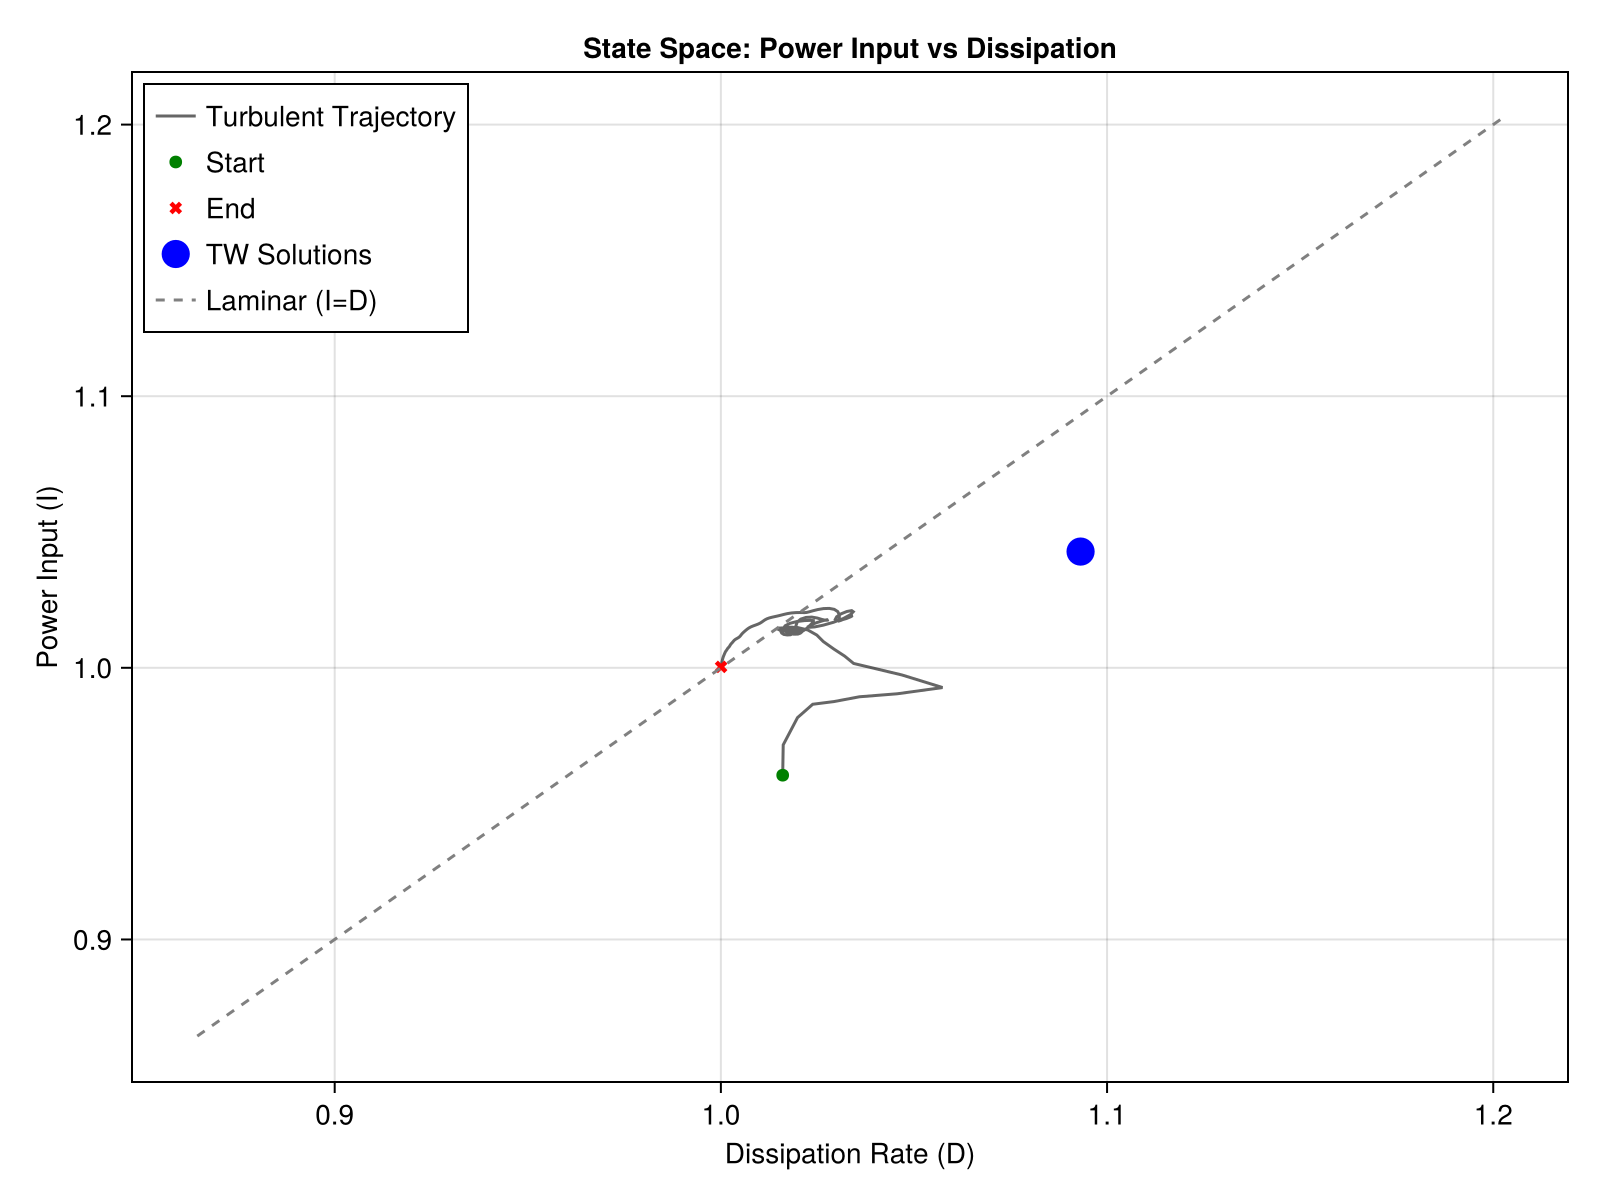

In [19]:
fig = plot_phase_space_map(model, solutions, edge_sol)

In [38]:
# 1. Generate a seed (random noise)
xnorm = 0.40
x_guess = randn(model.m)
x_seed = xnorm / norm(x_guess) * x_guess

# 2. Find the Edge Trajectory
# This is the "magic" step that filters out the junk
edge_sol = track_edge(model, Re, x_seed)

# 3. Harvest TWs from this edge trajectory
# Now the Newton solver has a fighting chance because we are physically close to the solution
# solutions, _, _, _ = harvest_solutions_from_trajectory(model, Re, edge_sol)
real_tws = harvest_solutions_smart(model, Re, edge_sol)

# 4. Check results
for sol in real_tws
    fp = get_fingerprint(model, sol)
    println("Found TW: cx=$(fp.cx), cz=$(fp.cz), norm=$(fp.nm)")
end


Verifying upper bound...
Starting Edge Tracking (Bisection)...
  Iter 1: α=0.5 -> turbulent
  Iter 2: α=0.25 -> turbulent
  Iter 3: α=0.125 -> turbulent
  Iter 4: α=0.0625 -> turbulent
  Iter 5: α=0.03125 -> turbulent
  Iter 6: α=0.015625 -> laminar
  Iter 7: α=0.0234375 -> laminar
  Iter 8: α=0.02734375 -> turbulent
  Iter 9: α=0.025390625 -> turbulent
  Iter 10: α=0.0244140625 -> laminar
  Iter 11: α=0.02490234375 -> laminar
  Iter 12: α=0.025146484375 -> laminar
  Iter 13: α=0.0252685546875 -> laminar
  Iter 14: α=0.02532958984375 -> turbulent
  Iter 15: α=0.025299072265625 -> laminar
Bisection complete. Refining edge state...
Building dissipation matrix...
Attempting harvest from 15 snapshots...
  t=8.0 (c_est=0.0)... Laminar.
  t=23.0 (c_est=0.0)... Laminar.
  t=34.0 (c_est=0.0)... Laminar.
  t=40.0 (c_est=0.0)... Laminar.
  t=46.0 (c_est=0.0)... Laminar.
  t=52.0 (c_est=0.0)... Laminar.
  t=60.0 (c_est=0.0)... Laminar.
  t=70.0 (c_est=0.0)... Laminar.
  t=84.0 (c_est=0.0)... Lami

In [43]:
"""
    harvest_asymmetric(symmetric_model, Re, sol_edge)

Harvests solutions using a full (no-symmetry) basis. 
This allows finding Traveling Waves that break the model's original symmetries.
"""
function harvest_asymmetric(symmetric_model::TWModel, Re::Real, sol_edge)
    println("--- Harvesting with Symmetry Breaking ---")
    
    # 1. Construct a Model with NO Symmetries
    # This expands the search space to include asymmetric Traveling Waves
    H_none = [CloudAtlas.Symmetry()] # Identity only
    
    # We copy the discretization params from the original model
    J, K, L = 1, 2, 3 # Ideally extract these from symmetric_model if stored, or pass manually
    # Note: If symmetric_model doesn't store J/K/L explicitly, ensure these match your script.
    
    # Create the "Open" Model
    model_full = TWModel(symmetric_model.α, symmetric_model.γ, J, K, L, H_none)
    
    solutions = []
    
    # 2. Identify Candidates (Slow points)
    D_mat = build_dissipation_matrix(symmetric_model)
    candidates, _, _, _ = find_trajectory_minima(symmetric_model, sol_edge, D_mat)
    
    if isempty(candidates)
        # Fallback: Try the last few frames if no minima found
        push!(candidates, (sol_edge.t[end], sol_edge.u[end]))
    end

    # 3. Harvest Loop
    for (t_val, u_sym) in candidates
        # A. Convert symmetric state -> full state
        # The basis indices differ, so we must project coefficients carefully.
        # (Function provided below)
        x_full = change_basis_to_full(symmetric_model, model_full, u_sym)
        
        # B. Estimate Wave Speed
        # We need to grab the previous snapshot to estimate speed
        idx = findfirst(t -> t >= t_val, sol_edge.t)
        if idx > 1
            u_prev_sym = sol_edge.u[idx-1]
            x_prev_full = change_basis_to_full(symmetric_model, model_full, u_prev_sym)
            dt = sol_edge.t[idx] - sol_edge.t[idx-1]
            
            # Using the helper from previous turn
            c_est = estimate_wave_speed(model_full, x_full, x_prev_full, dt)
        else
            c_est = 0.5 # Good initial guess for Lower Branch TWs
        end
        
        # C. Perturb Guess to Break Symmetry
        # Critical: Add random noise to the asymmetric modes
        x_perturbed = x_full + 0.05 * randn(length(model_full))
        
        ξ_guess = [x_perturbed; c_est; 0.0]
        
        print("  t=$t_val (c_guess=$(round(c_est, digits=3)))... ")
        
        # D. Solve using Full Model
        f(ξ) = model_full.g(ξ, Re)
        Df(ξ) = model_full.Dg(ξ, Re)
        
        # Looser tolerance for initial discovery
        params = SearchParams(Nnewton=40, Nhook=8, δ=0.05, ftol=1e-5)
        ξ_star, converged = hookstepsolve(f, Df, ξ_guess, params)
        
        if converged && norm(ξ_star[1:length(model_full)]) > 0.05
            cx_found = ξ_star[end-1]
            if abs(cx_found) > 0.001
                println("SUCCESS! Traveling Wave (cx=$(round(cx_found, digits=4)))")
                push!(solutions, ξ_star)
            else
                println("Converged to Stationary State (EQ).")
            end
        else
            println("Laminar or Diverged.")
        end
    end
    
    return solutions
end

"""
    change_basis_to_full(model_sym, model_full, x_sym)

Maps coefficients from a symmetric basis to a full basis.
"""
function change_basis_to_full(model_sym, model_full, x_sym)
    # Use the existing CloudAtlas `changebasis` utility
    # We match basis functions by their indices (i, j, k, l)
    return CloudAtlas.changebasis(x_sym, model_sym.ijkl, model_full.ijkl)
end

change_basis_to_full

In [44]:
# 1. Generate a seed (random noise)
xnorm = 0.40
x_guess = randn(model.m)
x_seed = xnorm / norm(x_guess) * x_guess

# 2. Find the Edge Trajectory
# This is the "magic" step that filters out the junk
edge_sol = track_edge(model, Re, x_seed)

# 3. Harvest TWs from this edge trajectory
# Now the Newton solver has a fighting chance because we are physically close to the solution
# solutions, _, _, _ = harvest_solutions_from_trajectory(model, Re, edge_sol)
real_tws = harvest_asymmetric(model, Re, edge_sol)

# 4. Check results
for sol in real_tws
    fp = get_fingerprint(model, sol)
    println("Found TW: cx=$(fp.cx), cz=$(fp.cz), norm=$(fp.nm)")
end


Verifying upper bound...
Starting Edge Tracking (Bisection)...
  Iter 1: α=0.5 -> turbulent
  Iter 2: α=0.25 -> turbulent
  Iter 3: α=0.125 -> turbulent
  Iter 4: α=0.0625 -> turbulent
  Iter 5: α=0.03125 -> turbulent
  Iter 6: α=0.015625 -> laminar
  Iter 7: α=0.0234375 -> laminar
  Iter 8: α=0.02734375 -> turbulent
  Iter 9: α=0.025390625 -> laminar
  Iter 10: α=0.0263671875 -> laminar
  Iter 11: α=0.02685546875 -> turbulent
  Iter 12: α=0.026611328125 -> turbulent
  Iter 13: α=0.0264892578125 -> turbulent
  Iter 14: α=0.02642822265625 -> turbulent
  Iter 15: α=0.026397705078125 -> turbulent
Bisection complete. Refining edge state...
--- Harvesting with Symmetry Breaking ---
J,K,L,m == 1,2,3,106
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B, A1, A2, Cx, Cz...
Phase constraints: keep_cx = true, keep_cz = true
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 5

In [45]:
base_dir="cont_results"
m = model.m
T = 10.0
symm_file = "./sxytxz.asc"

for ξ_star in real_tws
    timestamp = Dates.format(now(), "MM-DD-HHMMSS")
    sol_dir = joinpath(base_dir, "sol_$(J)_$(K)_$(L)_$(timestamp)")
    mkpath(sol_dir)
    guess_path = joinpath(sol_dir, "u_guess.nc")
    sigma_file = joinpath(sol_dir, "sigma.asc")
    
    coeff2field(ξ_star[1:m], model.ijkl, reference_field_converted, guess_path)
    save_sigma(model, ξ_star[end - 1], ξ_star[end], T, sigma_file)
    
    try
        findsoln(guess_path;
            R = Re, eqb = true, xrel = model.keep_cx, zrel = model.keep_cz,
            symms = abspath(symm_file), sigma = sigma_file, od = sol_dir, T = T
        )
    catch e
        println("findsoln failed: $e")
    end
end

alpha, gamma == 1.047197551196598, 1.570796326794897
Nx, Ny, Nz == 40, 49, 40
Reading ijkl indices of basis set from file
reading N == 53 ijkl indices
ijkl[0] == 1 0 0 1
L == max l == 3
Constructing Legendre polynomials
Assigning Polynomial, size = 1 
Assigning Polynomial, size = 0 1 
Assigning Polynomial, size = -0.5 0 1.5 
Assigning Polynomial, size = 0 -1.5 0 2.5 
Constructing S, and Sprime polynomials
Assigning Polynomial, size = 0 1 0 -0.3333333333333333 
Assigning Polynomial, size = 1 0 -2 0 1 
Assigning Polynomial, size = 0 1 0 -2 0 1 
Assigning Polynomial, size = -0.5 0 2.5 0 -3.5 0 1.5 
Assigning Polynomial, size = 1 0 -1 
Assigning Polynomial, size = 0 -4 0 4 
Assigning Polynomial, size = 1 0 -6 0 5 
Assigning Polynomial, size = 0 5 0 -14 0 9 
Generating psi[i]...
Computing innerproduct of u onto psi[1] to psi[53] ...
Loading expansion coeffs from file...Expanding projected field...
L2Norm(u)      == 0.2792590266581446
L2Norm(uout)   == 0.4777721010891809
L2Dist(u,uout) == 0.

f^T: .>.<10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.275443
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.0528667
   previous gx == 0.0528667
   current  gx == 0.0528667
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 0.00139745
   previous rx == 0.00139745
   current  rx == 0.00139745
         delta == 0.01
Newt,GMRES == 0,0, f^T: .>.<10 res == 0.973532
Newt,GMRES == 0,1, f^T: .>.<10 res == 0.970731
Newt,GMRES == 0,2, f^T: .>.<10 res == 0.97
Newt,GMRES == 0,3, f^T: .>.<10 res == 0.968873
Newt,GMRES == 0,4, f^T: .>.<10 res == 0.968161
Newt,GMRES == 0,5, f^T: .>.<10 res == 0.967169
Newt,GMRES == 0,6, f^T: .>.<10 res == 0.964711
Newt,GMRES == 0,7, f^T: .>.<10 res == 0.960023
Newt,GMRES == 0,8, f^T: .>.<10 res == 0.959213
Newt,GMRES == 0,9, f^T: .>.<10 res == 0.95813
Newt,GMRES == 0,10, f^T: .>.<10 res == 0.951214
Newt,GMRES == 0,11, 

f^T: ....10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.214651
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.0495021
   previous gx == 0.0495021
   current  gx == 0.0495021
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 0.00122523
   previous rx == 0.00122523
   current  rx == 0.00122523
         delta == 0.01
Newt,GMRES == 0,0, f^T: ....10 res == 0.985929
Newt,GMRES == 0,1, f^T: ....10 res == 0.985928
Newt,GMRES == 0,2, f^T: ....10 res == 0.984036
Newt,GMRES == 0,3, f^T: ....10 res == 0.977678
Newt,GMRES == 0,4, f^T: ....10 res == 0.977438
Newt,GMRES == 0,5, f^T: ....10 res == 0.977177
Newt,GMRES == 0,6, f^T: ....10 res == 0.974796
Newt,GMRES == 0,7, f^T: ....10 res == 0.972531
Newt,GMRES == 0,8, f^T: ....10 res == 0.918033
Newt,GMRES == 0,9, f^T: ....10 res == 0.917736
Newt,GMRES == 0,10, f^T: ....10 res == 0.917732
Newt,GMRES == 0

f^T: ....10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.146537
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.0422763
   previous gx == 0.0422763
   current  gx == 0.0422763
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 0.000893645
   previous rx == 0.000893645
   current  rx == 0.000893645
         delta == 0.01
Newt,GMRES == 0,0, f^T: ....10 res == 0.967228
Newt,GMRES == 0,1, f^T: ....10 res == 0.965718
Newt,GMRES == 0,2, f^T: ....10 res == 0.958821
Newt,GMRES == 0,3, f^T: ....10 res == 0.957992
Newt,GMRES == 0,4, f^T: ....10 res == 0.919097
Newt,GMRES == 0,5, f^T: ....10 res == 0.864376
Newt,GMRES == 0,6, f^T: ....10 res == 0.86205
Newt,GMRES == 0,7, f^T: ....10 res == 0.86004
Newt,GMRES == 0,8, f^T: ....10 res == 0.854083
Newt,GMRES == 0,9, f^T: ....10 res == 0.852412
Newt,GMRES == 0,10, f^T: ....10 res == 0.827021
Newt,GMRES == 

f^T: ....10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.0601651
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.011699
   previous gx == 0.011699
   current  gx == 0.011699
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 6.84336e-05
   previous rx == 6.84336e-05
   current  rx == 6.84336e-05
         delta == 0.01
Newt,GMRES == 0,0, f^T: ....10 res == 0.758908
Newt,GMRES == 0,1, f^T: ....10 res == 0.75296
Newt,GMRES == 0,2, f^T: ....10 res == 0.748864
Newt,GMRES == 0,3, f^T: ....10 res == 0.747839
Newt,GMRES == 0,4, f^T: ....10 res == 0.745429
Newt,GMRES == 0,5, f^T: ....10 res == 0.745419
Newt,GMRES == 0,6, f^T: ....10 res == 0.709928
Newt,GMRES == 0,7, f^T: ....10 res == 0.690511
Newt,GMRES == 0,8, f^T: ....10 res == 0.681261
Newt,GMRES == 0,9, f^T: ....10 res == 0.678098
Newt,GMRES == 0,10, f^T: ....10 res == 0.64172
Newt,GMRES == 0,